In [1]:
%load_ext autoreload
%autoreload 2
from typing import Literal
import torch
import torch.nn as nn   
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import sys
from csbdeep.utils import normalize
from scipy.ndimage import uniform_filter1d
from freq2clean import Freq2Clean
import json
import tifffile as tiff

sys.path.append("..")
from src import *

Cupy Available= 1


## Tune loss coefficients by their influence on the learned alpha values

In [22]:
selected_trainings = [
    "20251112-1153-synthetic_deepcad_150",
    "20251112-1054-synthetic_deepcad_150",
    "20251112-1044-synthetic_deepcad_150",
    "20251112-1038-synthetic_deepcad_150",
    "20251112-1034-synthetic_deepcad_150",
]

In [95]:
trainings = sorted(Path("trainings").glob("*"), reverse=True)
alphas = {}
losses = {}
for training_dir in selected_trainings:
    training_dir = Path("trainings") / training_dir
    cfg = json.load(open(training_dir / "cfg.json"))
    metrics = pd.read_csv(training_dir / "metrics.csv")
    ckpt = sorted((training_dir / "pth").glob("*.pt"), key=lambda file: int(file.stem))[-1]
    model = Freq2Clean(shape=(cfg["patch_t"],), mode="dft1d")
    model.load_state_dict(torch.load(ckpt))
    suffx = f"$w_{{L1}}={cfg["w_l1"]:.2f} \\;-\\; w_{{L2}}={cfg["w_mse"]:.2f} \\;-\\; w_{{\\rho}}={cfg["w_corr"]:.2f} \\;-\\; w_{{Reg}}={cfg["w_reg"]:.2f}$"
    alphas[suffx] = pd.Series(model.mask.detach().numpy())
    losses[suffx] = metrics["loss"]

Text(0, 0.5, 'Convex combination coefficient ($\\alpha_\\omega$)')

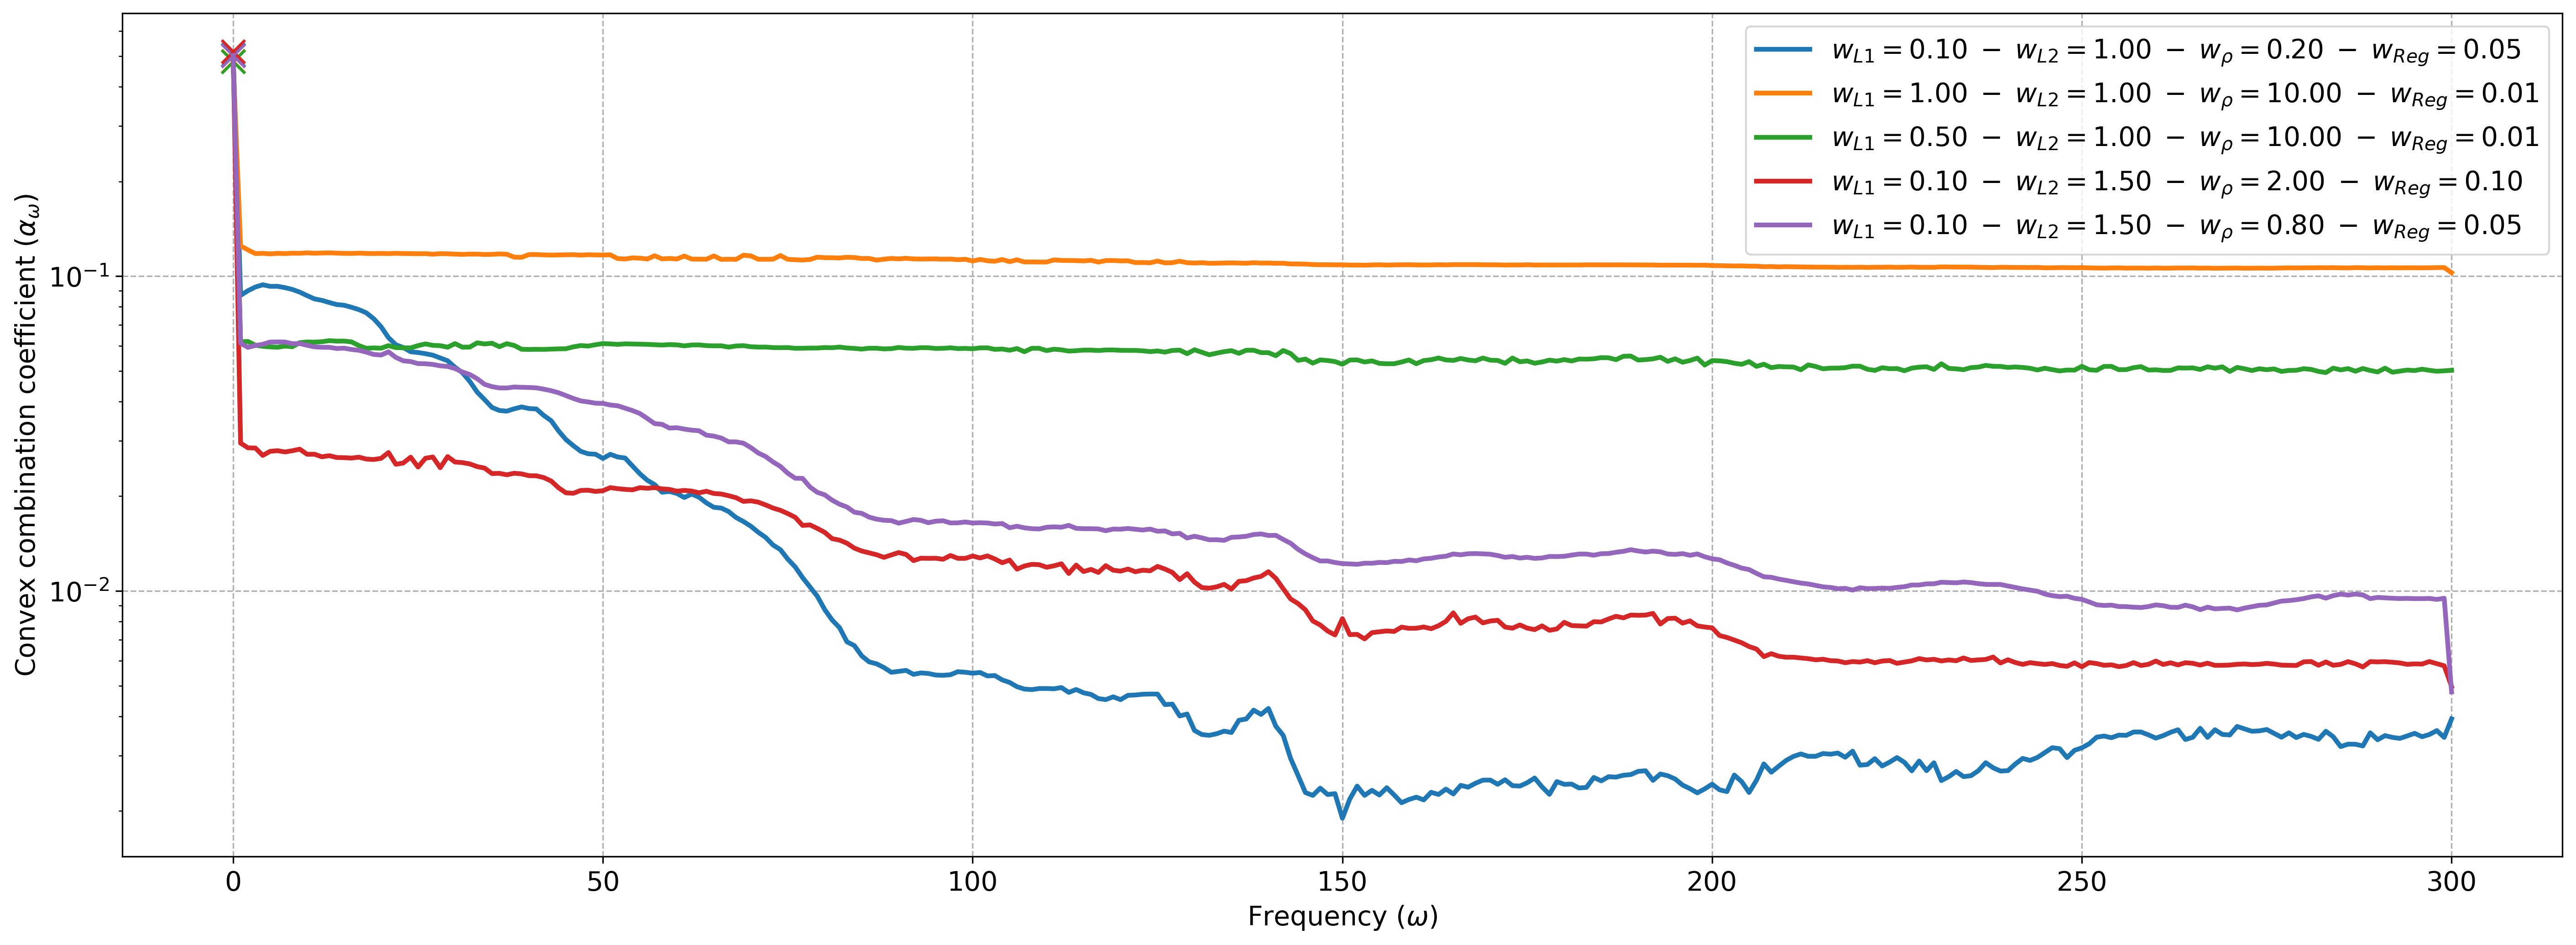

In [98]:
fig, ax = plt.subplots(figsize=(23, 8), dpi=300)
df = pd.DataFrame(alphas)
df.plot(ax=ax, linewidth=2.5)
for i, col in enumerate(df.columns):
    ax.scatter(0, df[col].iloc[0], s=150, marker="x")
plt.legend(prop={"family": "monospace"})
plt.yscale("log")
plt.xlabel("Frequency ($\\omega$)")
plt.ylabel("Convex combination coefficient ($\\alpha_\\omega$)")
# cprint(*[f"rand:{dir.stem}" for dir in trainings], sep="\n")

The $w_{l_1}= 1e^{-1},\quad w_{mse}= 1e^{-0},\quad w_{corr}= 2e^{-1},\quad w_{reg}= 5e^{-2}$ curve is the one we want.

In [ ]:
BATCH_SIZE = 1
CHANGE_FREQ0 = True
KEEP_ONLY_FREQ0 = True
device = "cuda" if torch.cuda.is_available() else "cpu"
SELECTED_TRAINING = "20251112-1153-synthetic_deepcad_150"
DENOISER_VARIANT: str | None = "_150"
cfg = json.load(open(f"trainings/{SELECTED_TRAINING}/cfg.json"))

In [4]:
x = Recording(f"dataset/{cfg["dataset_name"]}/x.tif", max_frames=None).normalized
y_ = Recording(
    f"dataset/{cfg["dataset_name"]}/{cfg["denoiser_name"]}{DENOISER_VARIANT or cfg["denoiser_variant"]}.tif", max_frames=None
).normalized
gt_ = Recording(f"dataset/{cfg["dataset_name"]}/gt.tif", max_frames=None).normalized
x_bar = uniform_filter1d(x, size=cfg["avg_win"], axis=0, mode="reflect")

In [5]:
overlap = 0.0
new_patcht = cfg["patch_t"] * (1 - overlap)
if overlap == 0:
    n = x.shape[0] // cfg["patch_t"]
    idx = (np.arange(n)[:, None] * cfg["patch_t"] + np.arange(cfg["patch_t"])).astype(int)
else:
    discard = math.ceil(1 / (1 - overlap) - 1)
    n = int(x.shape[0] // new_patcht)
    idx = (np.arange(n)[:-discard, None] * new_patcht + np.arange(cfg["patch_t"])).astype(int)

x = torch.from_numpy(x[idx]).float()
x_bar = torch.from_numpy(x_bar[idx]).float()
y = torch.from_numpy(y_[idx]).float()
gt = torch.from_numpy(gt_[idx]).float()
testset = TensorDataset(x, x_bar, y, gt)
dataloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)
del x, x_bar  # , y_, gt_
cprint(f"Testset has", len(idx), "samples.")

Testset has 10 samples.


In [ ]:
checkpointdir = Path("trainings") / SELECTED_TRAINING / "pth"
ckpt = sorted(checkpointdir.glob("*.pt"), key=lambda file: int(file.stem))[-1]
cprint("cyan:Loading checkpoint", ckpt.stem)
model = Freq2Clean(num_frames=cfg["patch_t"])
# model.alphas = nn.Parameter(torch.tensor([0.85] + [0.00] * (model.frames // 2)))
model.to(device)
model.load_state_dict(torch.load(ckpt, map_location=device))
model.eval()

# Test
f2cs = []
with torch.no_grad():
    if CHANGE_FREQ0:
        model.alphas[0] = 0.85
    if KEEP_ONLY_FREQ0:
        model.alphas[1:] = 0
    for x, x_bar, y, gt in tqdm(dataloader):
        out = model(y.to(device), x_bar.to(device))
        f2cs.append(out.cpu())

f2cs = torch.cat(f2cs, dim=0)
f2c = f2cs.reshape(-1, f2cs.shape[2], f2cs.shape[3]).numpy()

Loading checkpoint 19


100%|██████████| 10/10 [00:04<00:00,  2.17it/s]


In [8]:
ssim3d(f2c, gt_[: f2c.shape[0]], step=8), ssim3d(y_[: f2c.shape[0]], gt_[: f2c.shape[0]], step=8),

(0.8108663558959961, 0.7517234683036804)

ssim3d improves, yet the video loses temporal info

(310, 329)

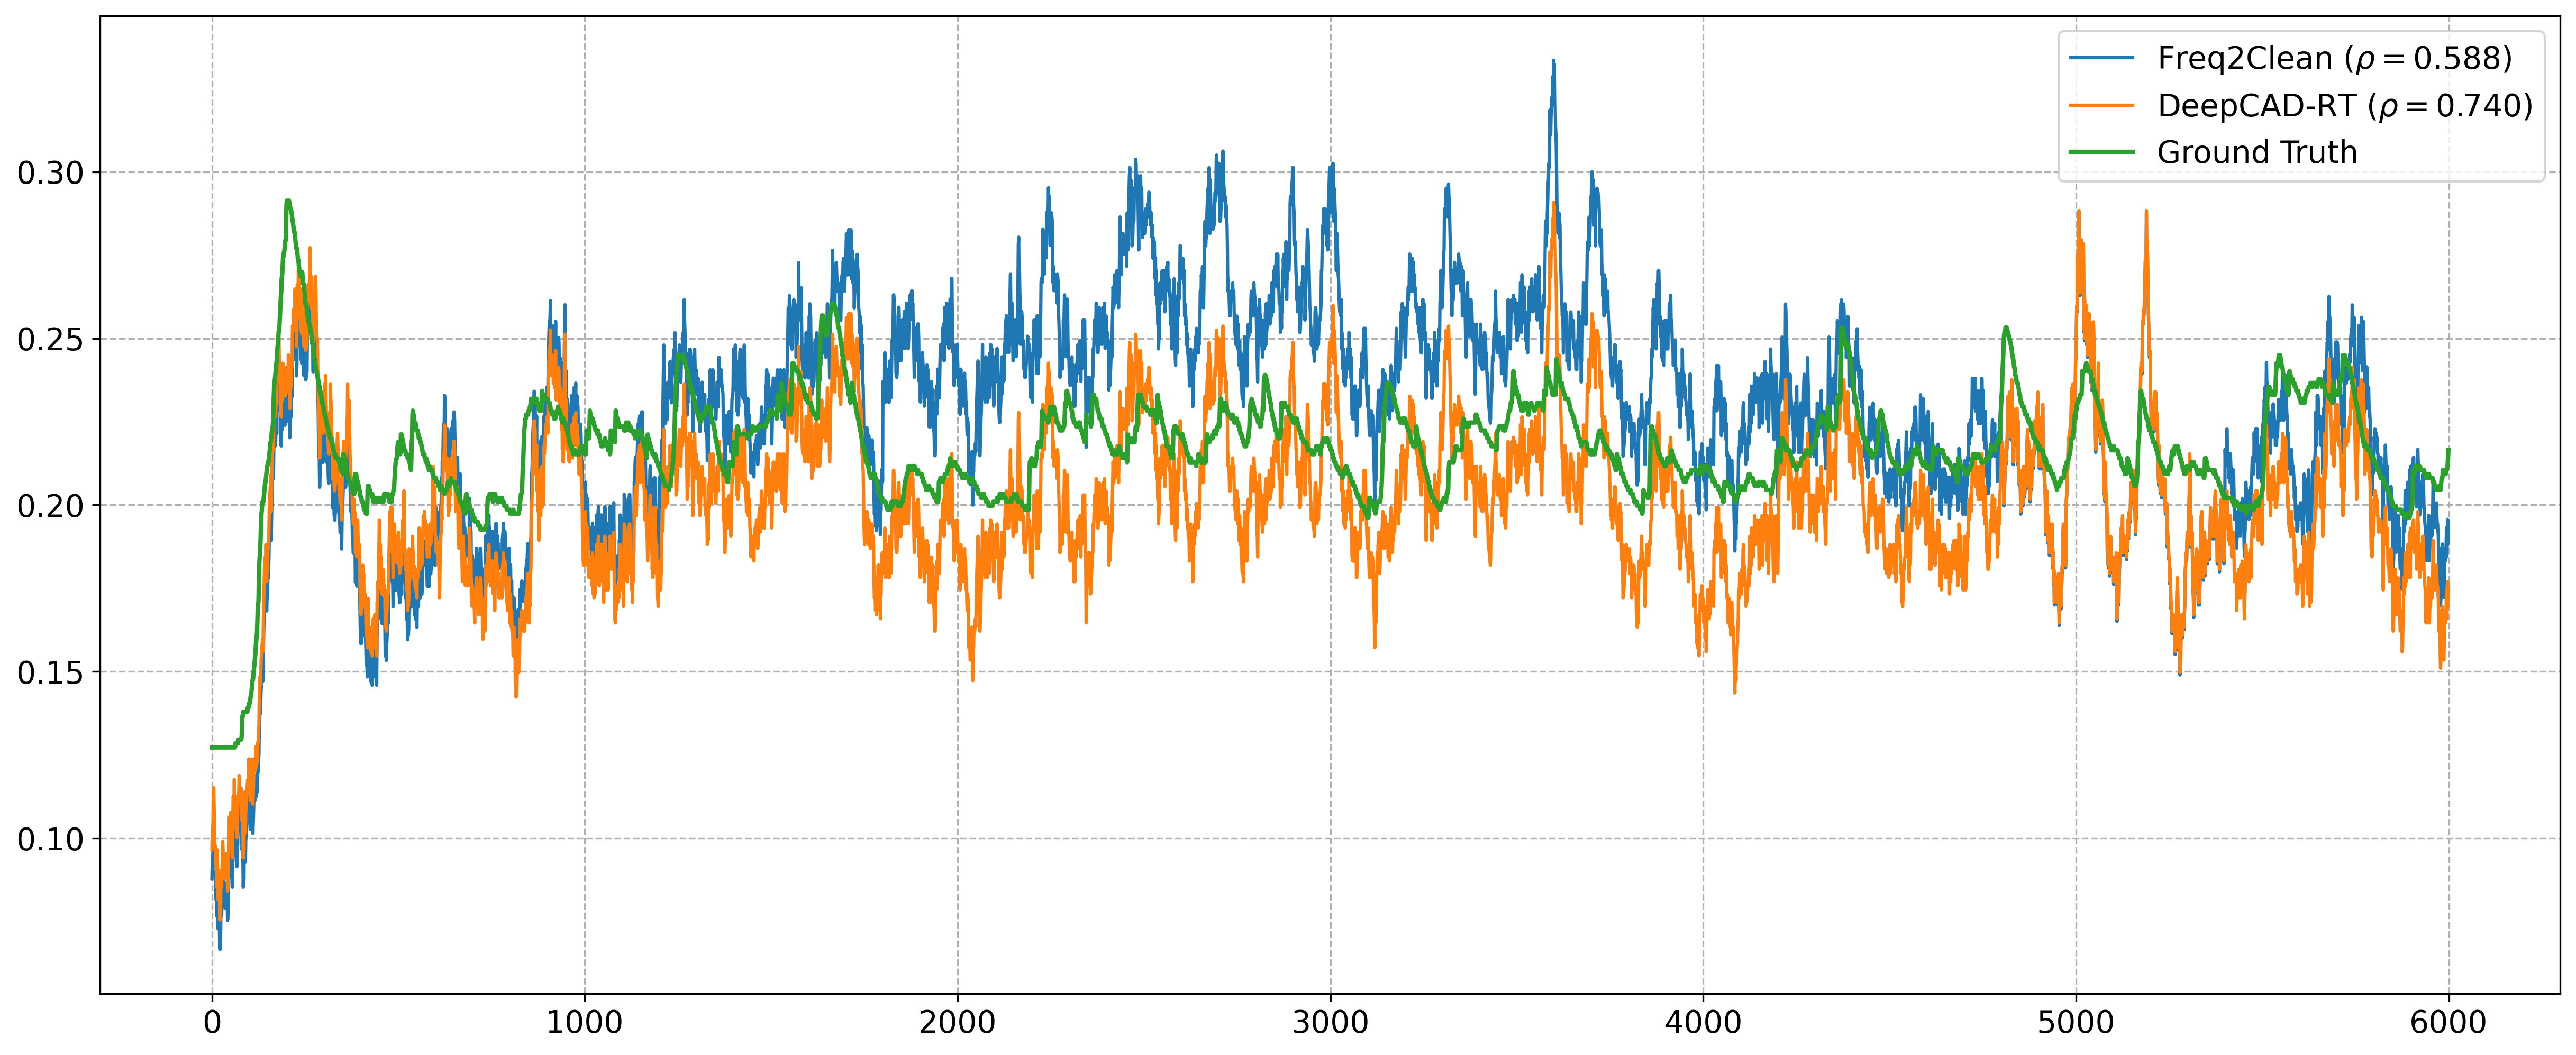

In [9]:
coord = random.randrange(490), random.randrange(490)
f2c_s = pd.Series(f2c[:, coord[0], coord[1]])
y_s = pd.Series(y_[:, coord[0], coord[1]])
gt_s = pd.Series(gt_[:, coord[0], coord[1]])

fig, ax = plt.subplots(figsize=(20, 8), dpi=300)
ax = f2c_s.plot(label=f"Freq2Clean ($\\rho={f2c_s.corr(gt_s):.3f}$)", ax=ax)
y_s.plot(ax=ax, label=f"DeepCAD-RT ($\\rho={y_s.corr(gt_s):.3f}$)")
gt_s.plot(ax=ax, label="Ground Truth", linewidth=2)
plt.legend()
coord

## Save results

In [10]:
tiff_dir = mkdir(f"results/{cfg["dataset_name"]}/{cfg["denoiser_name"]}{DENOISER_VARIANT or cfg["denoiser_variant"]}")
tiff.imwrite(tiff_dir / f"{SELECTED_TRAINING}{'_0.85' if CHANGE_FREQ0 else ''}{'_and_zeros' if KEEP_ONLY_FREQ0 else ''}.tiff", f2c)

## Generate recordings

In [ ]:
rec_path = Path(
    f"recordings/{cfg["dataset_name"]}/{cfg["denoiser_name"]}{cfg["denoiser_variant"]}/{SELECTED_TRAINING}.mp4"
)
Recording(f2c).render(rec_path, normalize=True)

In [ ]:
Editor().make_green(rec_path)

In [ ]:
Editor().alternate(
    {
        "DeepCAD-RT": rec_path.with_name("y_150.mp4"),
        "Freq2Clean": rec_path,
    },
    output=rec_path.with_name(f"{rec_path.stem}_alt 2x.mp4"),
    zoom=2,
)

In [2]:
import numpy as np

In [ ]:
np.indices(vid.shape).reshape(vid.ndim, -1).T